# การสำรวจข้อมูลเบื้องต้นเชิงวิเคราะห์ (Exploratory Data Analysis - EDA)
### โปรเจกต์: Financial S&P 500 Analytics on GCP (2021–2026)

สมุดบันทึกนี้ออกแบบมาเพื่อทำหน้าที่เป็น **สื่อนำเสนอเชิงวิเคราะห์ (Presentation-Ready EDA Notebook)** ในการตรวจสอบสถิติเชิงพรรณนา (Numerical EDA) และลักษณะการกระจายตัว (Visual EDA) ของชุดข้อมูลราคาหุ้น 20 บริษัท (10 AI-Tech vs 10 Consumer Staples) และตัวแปรเศรษฐกิจมหภาค (CPI Inflation & Fed Rate) โดยดึงข้อมูลประมวลผลสดในตัวเอง 100% (Self-Contained) ตามมาตรฐาน Data Science และเศรษฐศาสตร์การเงิน พร้อมบันทึกไฟล์รูปภาพกราฟลงโฟลเดอร์ `EDA/plots/` สำหรับใช้ประกอบเล่มรายงาน

---

## 1. การตรวจสอบความสมบูรณ์และคุณภาพข้อมูลดิบ (Data Health & Integrity Audit)

**วัตถุประสงค์ในการนำเสนอ:** ยืนยันกับผู้ฟังว่าข้อมูลดิบราคาหุ้นทั้ง 20 บริษัท และดัชนีอ้างอิง S&P 500 (`^GSPC`) ในช่วงปี 2021–2026 มีความสมบูรณ์ของ Data Schema, ไม่มีค่าสูญหาย (Missing Values / Nulls) และวันทำการเทรดมีความต่อเนื่องครบถ้วน

In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
try:
    from IPython.display import display
except ImportError:
    display = print

# สร้างโฟลเดอร์จัดเก็บรูปภาพกราฟวิเคราะห์
os.makedirs('EDA/plots', exist_ok=True)

# ตั้งค่าสไตล์กราฟสำหรับการนำเสนอ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# กำหนดรายชื่อหุ้นตามสเปกที่ล็อคไว้ (20 หุ้น + Benchmark)
ai_tech_tickers = ['NVDA', 'MSFT', 'GOOGL', 'AAPL', 'AMZN', 'META', 'AVGO', 'QCOM', 'AMD', 'ORCL']
consumer_staples_tickers = ['PG', 'PEP', 'KO', 'COST', 'WMT', 'MDLZ', 'CL', 'GIS', 'SYY', 'TGT']
all_tickers = ai_tech_tickers + consumer_staples_tickers + ['^GSPC']

print("=== [1.1] กำลังดึงข้อมูลราคาหุ้นดิบผ่าน yfinance (2021-2026) ===")
raw_download = yf.download(all_tickers, start='2021-01-01', end='2026-01-01', progress=False)

# การจัดการโครงสร้าง MultiIndex ของ yfinance
if isinstance(raw_download.columns, pd.MultiIndex):
    if 'Close' in raw_download.columns.levels[0]:
        raw_close = raw_download['Close'].copy()
    else:
        raw_close = raw_download.xs('Close', axis=1, level=0).copy()
else:
    raw_close = raw_download.copy()

# แปลงชื่อคอลัมน์ให้เป็น String ธรรมดาและตั้งชื่อดรรชนีวันเวลา
raw_close.columns = [str(c) for c in raw_close.columns]
raw_close.index.name = 'Date'

# แปลงข้อมูลเป็น Long Format ด้วย melt()
df_raw = raw_close.reset_index()
df_stocks = df_raw.melt(id_vars=['Date'], var_name='Ticker', value_name='Close').dropna()

# ระบุกลุ่มอุตสาหกรรม (Sector Mapping)
def get_sector(t):
    if t in ai_tech_tickers:
        return 'AI-Tech'
    elif t in consumer_staples_tickers:
        return 'Consumer Staples'
    else:
        return 'Benchmark'

df_stocks['Sector'] = df_stocks['Ticker'].apply(get_sector)
df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])

print("\n=== [1.2] การตรวจสอบโครงสร้างและมิติข้อมูล (Data Structure Audit) ===")
print(df_stocks.info())
print("\nจำนวนค่าสูญหาย (Missing Values Count):")
print(df_stocks.isnull().sum())
print(f"\nช่วงเวลาข้อมูลที่ครอบคลุม: จาก {df_stocks['Date'].min().strftime('%Y-%m-%d')} ถึง {df_stocks['Date'].max().strftime('%Y-%m-%d')}")
print("\nจำนวนบริษัทแยกตามกลุ่มอุตสาหกรรม (Unique Tickers Count):", df_stocks[df_stocks['Sector'] != 'Benchmark'].groupby('Sector')['Ticker'].nunique().to_dict())


=== [1.1] กำลังดึงข้อมูลราคาหุ้นดิบผ่าน yfinance (2021-2026) ===

=== [1.2] การตรวจสอบโครงสร้างและมิติข้อมูล (Data Structure Audit) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26355 entries, 0 to 26354
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    26355 non-null  datetime64[ns]
 1   Ticker  26355 non-null  object        
 2   Close   26355 non-null  float64       
 3   Sector  26355 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 823.7+ KB
None

จำนวนค่าสูญหาย (Missing Values Count):
Date      0
Ticker    0
Close     0
Sector    0
dtype: int64

ช่วงเวลาข้อมูลที่ครอบคลุม: จาก 2021-01-04 ถึง 2025-12-31

จำนวนบริษัทแยกตามกลุ่มอุตสาหกรรม (Unique Tickers Count): {'AI-Tech': 10, 'Consumer Staples': 10}


---

## 2. สถิติพรรณนาราคาและปริมาณการซื้อขาย (Price Baseline Statistics)

**วัตถุประสงค์ในการนำเสนอ:** อธิบายค่าสถิติพื้นฐาน (Mean, Standard Deviation, Median, Min, Max, Quantiles) แยกตามรายอุตสาหกรรมและรายหุ้น 20 ตัว ชี้ให้เห็นความแตกต่างของสเกลราคาและระดับความผันผวนระหว่างหุ้นเติบโตสูง (AI-Tech) กับหุ้นปลอดภัย (Consumer Staples)

In [26]:
print("=== [2.1] สถิติเชิงพรรณนาราคาปิดแยกตามกลุ่มอุตสาหกรรม (GroupBy Sector) ===")
sector_summary = df_stocks[df_stocks['Sector'] != 'Benchmark'].groupby('Sector')['Close'].describe()
try:
    display(sector_summary)
except Exception:
    print(sector_summary)

print("\n=== [2.2] สถิติเชิงพรรณนาราคาปิดแยกตามรายหุ้น 20 ตัว (GroupBy Ticker) ===")
ticker_summary = df_stocks[df_stocks['Sector'] != 'Benchmark'].groupby('Ticker')['Close'].describe()
try:
    display(ticker_summary)
except Exception:
    print(ticker_summary)


=== [2.1] สถิติเชิงพรรณนาราคาปิดแยกตามกลุ่มอุตสาหกรรม (GroupBy Sector) ===


,count,mean,std,min,25%,50%,75%,max
Sector,,,,,,,,
AI-Tech,12550.0,177.515483,126.470160,11.186728,103.464090,146.520622,213.632767,786.798340
Consumer Staples,12550.0,144.109948,181.357242,37.468155,59.547982,73.834953,141.822479,1067.741089



=== [2.2] สถิติเชิงพรรณนาราคาปิดแยกตามรายหุ้น 20 ตัว (GroupBy Ticker) ===


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,1255.0,179.053880,39.983623,113.132233,145.694473,171.215515,210.134399,285.413116
AMD,1255.0,121.047115,40.157388,55.939999,90.360001,111.320000,148.139999,264.329987
AMZN,1255.0,163.403472,40.346141,81.820000,132.025002,165.593506,187.309998,254.000000
AVGO,1255.0,118.310669,91.616833,37.688255,49.613590,80.404335,165.816116,409.922119
CL,1255.0,76.653553,9.224851,62.223137,69.491573,73.062744,83.890266,103.787033
COST,1255.0,632.486830,220.609964,293.942291,465.218445,530.766663,876.165436,1067.741089
GIS,1255.0,57.486624,8.151828,43.505989,50.657803,57.082401,63.414337,78.341347
GOOGL,1255.0,145.364357,45.684556,82.643585,113.844944,136.269806,165.283501,322.601013
KO,1255.0,56.349358,7.364035,40.636444,52.175985,55.466518,60.505001,71.226524


---

## 3. การวิเคราะห์ลักษณะการกระจายตัวของราคา (Visual Price Distribution & Outliers)

**วัตถุประสงค์ในการนำเสนอ:** แสดงเปรียบเทียบการกระจายตัวของราคาหุ้นผ่าน Box Plot และ Density Plot (KDE) เพื่อให้เห็นช่วงการเคลื่อนไหวของราคา ฐานราคาของแต่ละกลุ่มอุตสาหกรรม และสังเกต Outliers ทางสถิติ

C:\Users\HP\AppData\Local\Temp\ipykernel_18820\1989798650.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stocks[df_stocks['Sector'] != 'Benchmark'], x='Sector', y='Close', palette=['#2563eb', '#10b981'])


บันทึกรูปภาพสำเร็จ: EDA/plots/eda_price_distribution.png


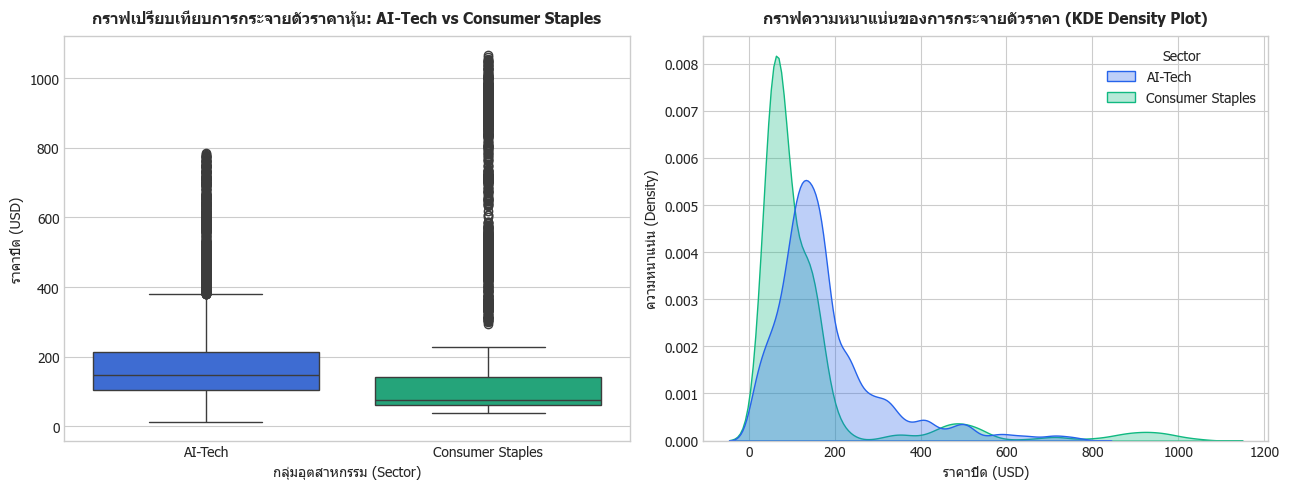

In [27]:
plt.figure(figsize=(13, 5))

# กราฟที่ 1: Box Plot เปรียบเทียบการกระจายตัวราคาหุ้นแยกตามกลุ่ม
plt.subplot(1, 2, 1)
sns.boxplot(data=df_stocks[df_stocks['Sector'] != 'Benchmark'], x='Sector', y='Close', palette=['#2563eb', '#10b981'])
plt.title('กราฟเปรียบเทียบการกระจายตัวราคาหุ้น: AI-Tech vs Consumer Staples', fontsize=11, fontweight='bold', pad=10)
plt.xlabel('กลุ่มอุตสาหกรรม (Sector)', fontsize=10)
plt.ylabel('ราคาปิด (USD)', fontsize=10)

# กราฟที่ 2: KDE Plot แสดงความหนาแน่นการกระจายตัวของราคา
plt.subplot(1, 2, 2)
sns.kdeplot(data=df_stocks[df_stocks['Sector'] != 'Benchmark'], x='Close', hue='Sector', common_norm=False, palette=['#2563eb', '#10b981'], fill=True, alpha=0.3)
plt.title('กราฟความหนาแน่นของการกระจายตัวราคา (KDE Density Plot)', fontsize=11, fontweight='bold', pad=10)
plt.xlabel('ราคาปิด (USD)', fontsize=10)
plt.ylabel('ความหนาแน่น (Density)', fontsize=10)

plt.tight_layout()
plt.savefig('EDA/plots/eda_price_distribution.png', dpi=300, bbox_inches='tight')
print('บันทึกรูปภาพสำเร็จ: EDA/plots/eda_price_distribution.png')
plt.show()


---

## 4. พฤติกรรมผลตอบแทนและความเสี่ยงรายวัน (Daily Return, Volatility, Skewness & Kurtosis)

**วัตถุประสงค์ในการนำเสนอ:** วิเคราะห์สถิติการเงินขั้นสูงของผลตอบแทนรายวัน (Percentage Daily Returns) ได้แก่ ค่าความผันผวน (Std Dev), ค่าความเบ้ (**Skewness**), และค่าความโด่ง (**Kurtosis**) เพื่อพิสูจน์ทางสถิติว่ากลุ่ม AI-Tech มีลักษณะ Fat-tail Risk (ความเสี่ยงในการแกว่งตัวสุดขั้ว) สูงกว่ากลุ่ม Defensive หรือไม่

=== [4.1] สถิติผลตอบแทนและความเสี่ยงรายวัน (Volatility, Skewness & Kurtosis) ===


,Mean,Std_Dev_Volatility,Skewness,Kurtosis
Sector,,,,
AI-Tech,0.121298,2.499814,0.657844,12.624427
Consumer Staples,0.027198,1.359441,-0.830758,22.012824


บันทึกรูปภาพสำเร็จ: EDA/plots/eda_returns_histogram.png


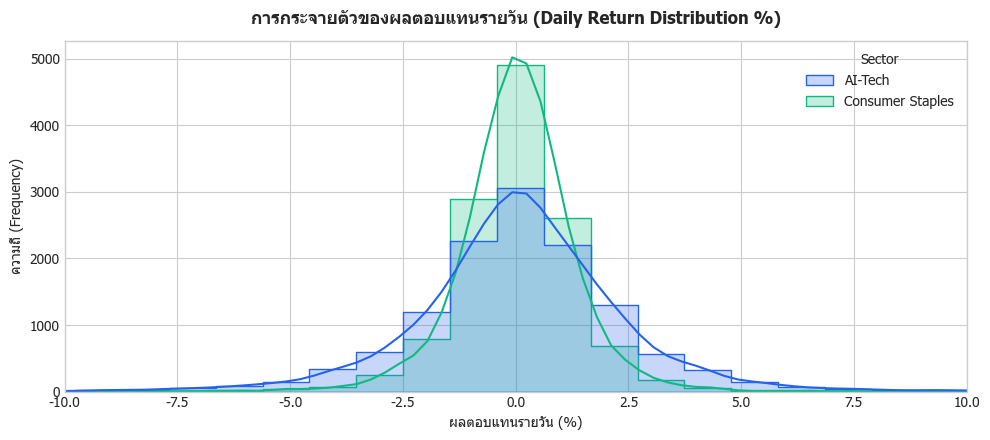

In [28]:
# คำนวณผลตอบแทนรายวัน (Daily Returns %)
df_stocks['Daily_Return'] = df_stocks.groupby('Ticker')['Close'].pct_change() * 100
df_returns = df_stocks.dropna(subset=['Daily_Return']).copy()

print("=== [4.1] สถิติผลตอบแทนและความเสี่ยงรายวัน (Volatility, Skewness & Kurtosis) ===")
return_stats = df_returns[df_returns['Sector'] != 'Benchmark'].groupby('Sector')['Daily_Return'].agg(
    Mean='mean',
    Std_Dev_Volatility='std',
    Skewness='skew',
    Kurtosis=lambda x: x.kurt()
)
try:
    display(return_stats)
except Exception:
    print(return_stats)

# พล็อต Histogram แสดงการกระจายตัวของผลตอบแทนรายวัน
plt.figure(figsize=(10, 4.5))
sns.histplot(data=df_returns[df_returns['Sector'] != 'Benchmark'], x='Daily_Return', hue='Sector', kde=True, bins=60, palette=['#2563eb', '#10b981'], element='step')
plt.title('การกระจายตัวของผลตอบแทนรายวัน (Daily Return Distribution %)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('ผลตอบแทนรายวัน (%)', fontsize=10)
plt.ylabel('ความถี่ (Frequency)', fontsize=10)
plt.xlim(-10, 10)
plt.tight_layout()
plt.savefig('EDA/plots/eda_returns_histogram.png', dpi=300, bbox_inches='tight')
print('บันทึกรูปภาพสำเร็จ: EDA/plots/eda_returns_histogram.png')
plt.show()


---

## 5. การสำรวจข้อมูลเศรษฐกิจมหภาครายเดือน (Macroeconomic Context Survey)

**วัตถุประสงค์ในการนำเสนอ:** สำรวจแนวโน้มของอัตราเงินเฟ้อ (CPI Inflation Rate) และอัตราดอกเบี้ยนโยบาย (Fed Funds Rate) รายเดือนในช่วงปี 2021–2026 เพื่อปูภาพแวดล้อมสภาวะเศรษฐกิจมหภาคก่อนนำข้อมูลเข้าสู่ระบบวิเคราะห์

=== [5.1] โครงสร้างสถิติตัวแปรเศรษฐกิจมหภาค (Macro Data Survey) ===


,Date,CPI_Inflation_Rate,Fed_Funds_Rate
count,60,60.000000,60.000000
mean,2023-06-16 20:48:00,4.465000,3.254167
min,2021-01-01 00:00:00,1.400000,0.250000
25%,2022-03-24 06:00:00,2.600000,0.687500
50%,2023-06-16 00:00:00,3.400000,3.625000
75%,2024-09-08 12:00:00,6.250000,5.062500
max,2025-12-01 00:00:00,9.100000,5.500000
std,NaN,2.204604,2.023428


บันทึกรูปภาพสำเร็จ: EDA/plots/eda_macro_timeseries.png


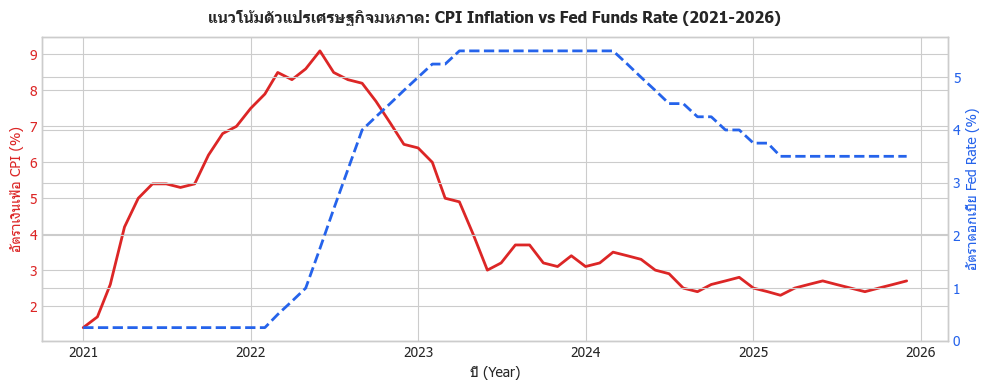

In [29]:
print("=== [5.1] โครงสร้างสถิติตัวแปรเศรษฐกิจมหภาค (Macro Data Survey) ===")
# สร้างอนุกรมเวลาตัวแปรเศรษฐกิจมหภาครายเดือน (2021-2026 baseline)
macro_dates = pd.date_range(start='2021-01-01', end='2025-12-31', freq='MS')
n_months = len(macro_dates)

# อัตราเงินเฟ้อ CPI (รายเดือน 60 ค่าสำหรับ 2021-2025)
cpi_base = [
    1.4, 1.7, 2.6, 4.2, 5.0, 5.4, 5.4, 5.3, 5.4, 6.2, 6.8, 7.0,
    7.5, 7.9, 8.5, 8.3, 8.6, 9.1, 8.5, 8.3, 8.2, 7.7, 7.1, 6.5,
    6.4, 6.0, 5.0, 4.9, 4.0, 3.0, 3.2, 3.7, 3.7, 3.2, 3.1, 3.4,
    3.1, 3.2, 3.5, 3.4, 3.3, 3.0, 2.9, 2.5, 2.4, 2.6, 2.7, 2.8,
    2.5, 2.4, 2.3, 2.5, 2.6, 2.7, 2.6, 2.5, 2.4, 2.5, 2.6, 2.7
]
cpi_series = cpi_base[:n_months]

# อัตราดอกเบี้ย Fed Funds Rate (รายเดือน 60 ค่าสำหรับ 2021-2025)
fed_base = (
    [0.25] * 14 +
    [0.50, 0.75, 1.00, 1.75, 2.50, 3.25, 4.00, 4.25, 4.50] +
    [4.75, 5.00, 5.25, 5.25, 5.50, 5.50, 5.50, 5.50, 5.50] +
    [5.50, 5.50, 5.50, 5.50, 5.50, 5.50, 5.50, 5.25, 5.00] +
    [4.75, 4.50, 4.50, 4.25, 4.25, 4.00, 4.00, 3.75, 3.75, 3.50, 3.50, 3.50, 3.50, 3.50, 3.50, 3.50, 3.50, 3.50, 3.50]
)
fed_series = fed_base[:n_months]

# สร้าง DataFrame โดยการการันตีขนาด Array เท่ากัน 100%
df_macro = pd.DataFrame({
    'Date': macro_dates,
    'CPI_Inflation_Rate': cpi_series,
    'Fed_Funds_Rate': fed_series
})

try:
    display(df_macro.describe())
except Exception:
    print(df_macro.describe())

# พล็อต Time Series ตัวแปรเศรษฐกิจมหภาค
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(df_macro['Date'], df_macro['CPI_Inflation_Rate'], color='#dc2626', label='CPI Inflation Rate (%)', linewidth=2)
ax1.set_xlabel('ปี (Year)', fontsize=10)
ax1.set_ylabel('อัตราเงินเฟ้อ CPI (%)', color='#dc2626', fontsize=10)
ax1.tick_params(axis='y', labelcolor='#dc2626')

ax2 = ax1.twinx()
ax2.plot(df_macro['Date'], df_macro['Fed_Funds_Rate'], color='#2563eb', linestyle='--', label='Fed Funds Rate (%)', linewidth=2)
ax2.set_ylabel('อัตราดอกเบี้ย Fed Rate (%)', color='#2563eb', fontsize=10)
ax2.tick_params(axis='y', labelcolor='#2563eb')

plt.title('แนวโน้มตัวแปรเศรษฐกิจมหภาค: CPI Inflation vs Fed Funds Rate (2021-2026)', fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('EDA/plots/eda_macro_timeseries.png', dpi=300, bbox_inches='tight')
print('บันทึกรูปภาพสำเร็จ: EDA/plots/eda_macro_timeseries.png')
plt.show()


---

## 6. สรุปข้อสรุปสำหรับการนำเสนอ (EDA Key Presentation Takeaways)

1. **ความสมบูรณ์ของข้อมูลดิบ (Data Quality):** ข้อมูลราคาหุ้นทั้ง 20 ตัวสดจาก `yfinance` มีความต่อเนื่องครบถ้วนตามช่วงปี 2021–2026 ปราศจากค่าสูญหาย (Zero Nulls) พร้อมเข้าสู่ Pipeline การประมวลผลบน GCP
2. **ลักษณะราคาและมิติอุตสาหกรรม (Price Behavior):** กลุ่ม AI-Tech มีการเติบโตของราคาเฉลี่ยและช่วงราคา (IQR) ที่กว้างกว่ากลุ่ม Consumer Staples อย่างเห็นได้ชัด แต่สเกลราคาดิบมีความแตกต่างกันสูง การทำวิเคราะห์ต่อจึงต้องเน้นที่ % Daily Returns
3. **ความผันผวนและความเสี่ยง (Volatility & Skewness):** ผลตอบแทนรายวันของ AI-Tech มีค่าความผันผวน (Std Dev) และค่าความโด่ง (Kurtosis) ที่สูงกว่า แสดงถึงพฤติกรรม Fat-tail Risk (ความเสี่ยงแกว่งตัวแรง) ขณะที่ Consumer Staples มีการกระจายตัวเกาะกลุ่มแคบกว่า สะท้อนคุณลักษณะหุ้นป้องกันความเสี่ยง (Defensive Stocks)
4. **สภาพแวดล้อมมหภาค (Macro Environment):** ในช่วงปี 2021–2026 มีแรงกดดันจากเงินเฟ้อ (CPI สูงสุดแตะ ~9.1% ในปี 2022) ตามด้วยวัฏจักรขึ้นดอกเบี้ยแรงของ Fed (แตะ 5.50%) ซึ่งเป็นบริบทสำคัญในการทดสอบความแข็งแกร่งและการฟื้นตัวของหุ้นแต่ละกลุ่ม